In [1]:
# all the libraries i have used
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl

In [2]:
# I was not able to load train dataset the way i loaded test dataset so I learnt this method from AI
!pip install -q gdown

import gdown
import pandas as pd

file_id = "11n00bAs7TU3H_7GE86tia5rsB-ax4XXy"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=True)

df_train = pd.read_csv("data.csv")
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_test = pd.read_csv('https://drive.google.com/uc?id=1bvbOveIMLFbU2Vnw6LwghYyxK1caH4C1')
df_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df_train.shape

(60000, 785)

In [5]:
df_test.shape

(10000, 785)

In [6]:
#defining training set(taking out label as y output)
x_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values

#similarly defining test set
x_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values


In [7]:
#normalising bw 0 and 1
x_train = x_train/255
x_test = x_test/255

In [8]:
#converting to torch
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [9]:
#turning into dataset
dataset = TensorDataset(x_train, y_train)


In [10]:

#spliting into train and validation dataset(used a bit of AI)
train = int(0.75*len(dataset))
val = len(dataset) - train

train_dataset, val_dataset = random_split(dataset, [train, val])

#dataloader to impprove efficiency by regrouping into small batches and shuffling training set to avoid output memorisation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



In [11]:
class MyNeuralNetwork(nn.Module):

  def __init__(self):
    super().__init__()

    #defining model
    #initial part of the model
    self.base = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 16),
        nn.ReLU()
    )

    #the right branch
    self.right1 = nn.Sequential(
        nn.Linear(16, 12),
        nn.ReLU(),
        nn.Linear(12, 8),
        nn.ReLU()
    )

    #the left branch
    self.left1 = nn.Sequential(
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 8),
        nn.ReLU()
    )

    #the output layer
    self.output = nn.Sequential(
        nn.Linear(16, 10)
    )


  #defining forward pass
  def forward(self, x):

      x = self.base(x)

      #right path
      right = self.right1(x)

      #left path with skip connection(took a bit of help from AI)
      left1 = self.left1[0](x)
      left2 = self.left1[2](self.left1[1](left1))
      left = self.left1[3](left2 + left1)

      #Concatonate both branched to get single output
      combine = torch.cat([left, right], dim=1)

      return self.output(combine)



In [12]:
model = MyNeuralNetwork()

#using inbuilt Cross Entropy loss function
loss_function = nn.CrossEntropyLoss()

#using Adam for updationg weights
optimizer = optim.Adam(model.parameters(), lr=0.0003)

num_epoch = 30



In [13]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []


for epoch in range(num_epoch):

    # setting model to training mode
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x_batch, y_batch in train_loader:

        # forward pass
        y_pred = model(x_batch)

        # calculating loss
        loss = loss_function(y_pred, y_batch)

        # clearing gradients from last step
        optimizer.zero_grad()

        # backward pass
        loss.backward()

        # updating weights
        optimizer.step()

        # keeping track of loss and accuracy over all batches
        total_loss += loss.item()
        correct += (torch.argmax(y_pred, 1) == y_batch).sum().item()
        total += y_batch.size(0)

    # storing average loss and accuracy for this epoch
    train_losses.append(total_loss / len(train_loader))
    train_accs.append(correct / total)

    # switching to eval mode so dropout/batchnorm behave differently (not used here but good practice)
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0

    # no need to calculate gradients during validation
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred = model(x_batch)
            v_loss += loss_function(y_pred, y_batch).item()
            v_correct += (torch.argmax(y_pred, 1) == y_batch).sum().item()
            v_total += y_batch.size(0)

    val_losses.append(v_loss / len(val_loader))
    val_accs.append(v_correct / v_total)

    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Train Acc={train_accs[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")






Epoch 1: Train Loss=0.9724, Val Loss=0.6242, Train Acc=0.6512, Val Acc=0.7753
Epoch 2: Train Loss=0.5672, Val Loss=0.5455, Train Acc=0.7983, Val Acc=0.8047
Epoch 3: Train Loss=0.5018, Val Loss=0.4841, Train Acc=0.8268, Val Acc=0.8282
Epoch 4: Train Loss=0.4702, Val Loss=0.4667, Train Acc=0.8384, Val Acc=0.8326
Epoch 5: Train Loss=0.4508, Val Loss=0.4446, Train Acc=0.8449, Val Acc=0.8417
Epoch 6: Train Loss=0.4343, Val Loss=0.4470, Train Acc=0.8511, Val Acc=0.8393
Epoch 7: Train Loss=0.4227, Val Loss=0.4227, Train Acc=0.8541, Val Acc=0.8503
Epoch 8: Train Loss=0.4126, Val Loss=0.4176, Train Acc=0.8572, Val Acc=0.8526
Epoch 9: Train Loss=0.4030, Val Loss=0.4140, Train Acc=0.8604, Val Acc=0.8553
Epoch 10: Train Loss=0.3968, Val Loss=0.4077, Train Acc=0.8629, Val Acc=0.8561
Epoch 11: Train Loss=0.3902, Val Loss=0.4113, Train Acc=0.8641, Val Acc=0.8544
Epoch 12: Train Loss=0.3864, Val Loss=0.4024, Train Acc=0.8660, Val Acc=0.8564
Epoch 13: Train Loss=0.3812, Val Loss=0.4017, Train Acc=0.867

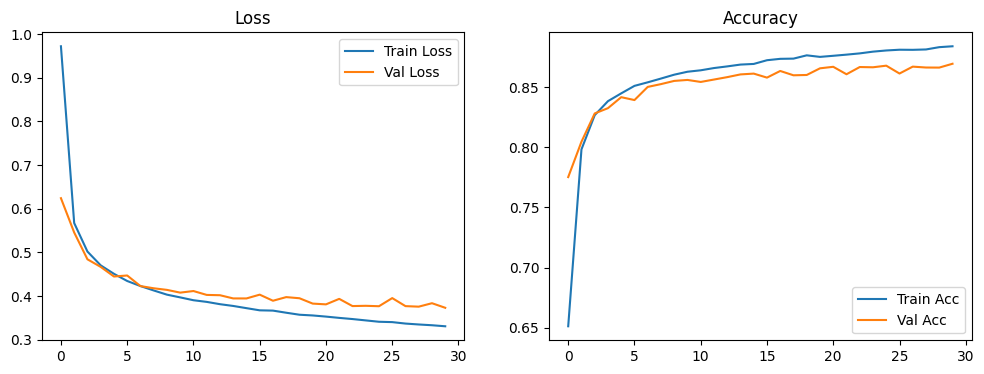

In [14]:
# Ploting graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss'); ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(train_accs, label='Train Acc'); ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Accuracy'); ax2.legend()
plt.show()

In [15]:
#getting predictions
model.eval()

with torch.no_grad():

  y_pred = model(x_test)
  prediction = torch.argmax(y_pred, dim=1)

print(prediction)

tensor([0, 1, 2,  ..., 8, 8, 1])


In [16]:
prediction = prediction.numpy()

In [17]:
# test accuracy
correct = (prediction == y_test.numpy()).sum()
total = len(y_test)
print(f"Test Accuracy: {correct/total*100:.2f}%")

Test Accuracy: 87.12%


In [18]:
# saving weights with pickle
with open("model_weights.pkl", "wb") as f:
    pkl.dump(model.state_dict(), f)

In [20]:
from google.colab import files
files.download("model_weights.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
submission = pd.DataFrame({
    "ID" : range(1,10001),
    "Labels" : prediction
})
submission.to_csv("submission.csv", index=False)


In [22]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>